Running simulation...
Step 0/500
Step 5/500
Step 10/500
Step 15/500
Step 20/500
Step 25/500
Step 30/500
Step 35/500
Step 40/500
Step 45/500
Step 50/500
Step 55/500
Step 60/500
Step 65/500
Step 70/500
Step 75/500
Step 80/500
Step 85/500
Step 90/500
Step 95/500
Step 100/500
Step 105/500
Step 110/500
Step 115/500
Step 120/500
Step 125/500
Step 130/500
Step 135/500
Step 140/500
Step 145/500
Step 150/500
Step 155/500
Step 160/500
Step 165/500
Step 170/500
Step 175/500
Step 180/500
Step 185/500
Step 190/500
Step 195/500
Step 200/500
Step 205/500
Step 210/500
Step 215/500
Step 220/500
Step 225/500
Step 230/500
Step 235/500
Step 240/500
Step 245/500
Step 250/500
Step 255/500
Step 260/500
Step 265/500
Step 270/500
Step 275/500
Step 280/500
Step 285/500
Step 290/500
Step 295/500
Step 300/500
Step 305/500
Step 310/500
Step 315/500
Step 320/500
Step 325/500
Step 330/500
Step 335/500
Step 340/500
Step 345/500
Step 350/500
Step 355/500
Step 360/500
Step 365/500
Step 370/500
Step 375/500
Step 380/500

/home/clesio/miniconda3/envs/py313/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


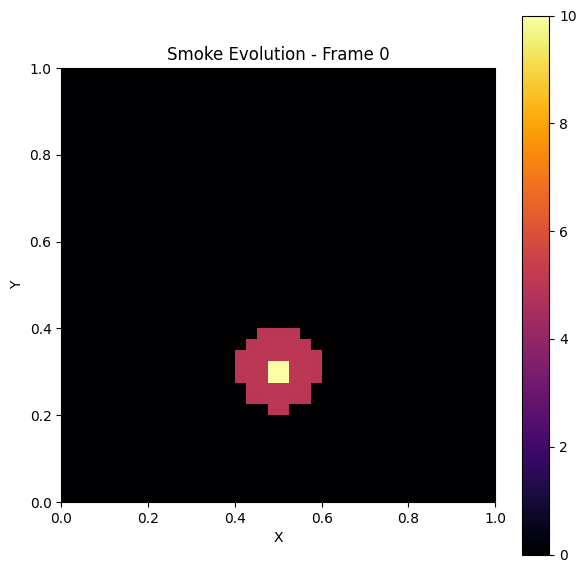

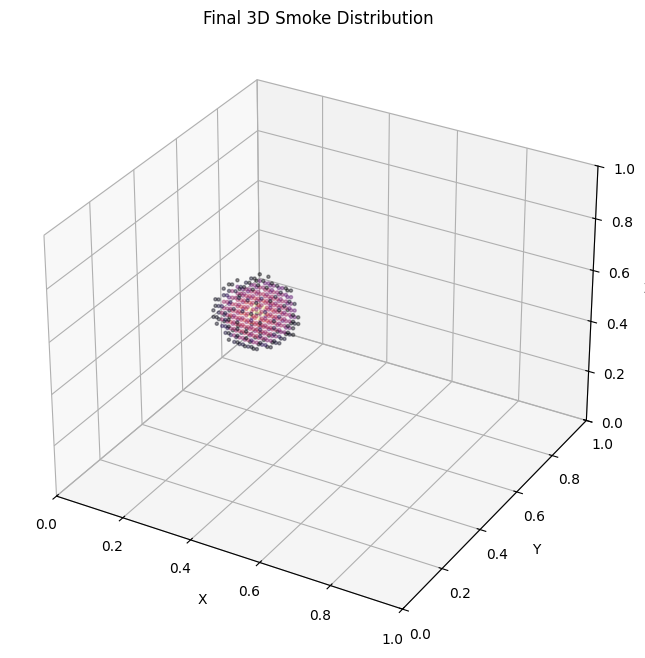


Maximum divergence:
0.0013834668572695146


In [3]:
#============================================================
# 3D Incompressible Flow and Scalar Transport Smoke Simulation
# ============================================================
#
# This notebook simulates:
# - 3D incompressible fluid flow
# - Passive scalar transport (smoke concentration)
# - Advection and diffusion
# - Pressure projection method
# - Real-time 3D visualization
#
# Author: OpenAI ChatGPT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# ============================================================
# DOMAIN
# ============================================================

Nx = 40
Ny = 40
Nz = 40

Lx = 1.0
Ly = 1.0
Lz = 1.0

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
dz = Lz / (Nz - 1)

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
z = np.linspace(0, Lz, Nz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ============================================================
# PHYSICAL PARAMETERS
# ============================================================

rho = 1.0

nu = 0.002
D = 0.0005

dt = 0.0005
nt = 500

# ============================================================
# INITIAL VELOCITY FIELD
# ============================================================

u_x = -0.15 * (Y - 0.5)
u_y =  0.15 * (X - 0.5)
u_z =  0.02 * np.sin(2*np.pi*Z)

# ============================================================
# PRESSURE FIELD
# ============================================================

p = np.zeros((Nx, Ny, Nz))

# ============================================================
# SMOKE FIELD
# ============================================================

smoke = np.zeros((Nx, Ny, Nz))

# Initial smoke sphere

cx, cy, cz = 0.30, 0.50, 0.50
radius = 0.10

mask = (
    (X - cx)**2 +
    (Y - cy)**2 +
    (Z - cz)**2
) < radius**2

smoke[mask] = 5.0

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

def apply_boundary(u):

    u[0,:,:]  = 0
    u[-1,:,:] = 0

    u[:,0,:]  = 0
    u[:,-1,:] = 0

    u[:,:,0]  = 0
    u[:,:,-1] = 0

    return u

# ============================================================
# DIVERGENCE
# ============================================================

def divergence(u, v, w):

    div = np.zeros_like(u)

    div[1:-1,1:-1,1:-1] = (

        (u[2:,1:-1,1:-1] - u[:-2,1:-1,1:-1]) / (2*dx)

        +

        (v[1:-1,2:,1:-1] - v[1:-1,:-2,1:-1]) / (2*dy)

        +

        (w[1:-1,1:-1,2:] - w[1:-1,1:-1,:-2]) / (2*dz)

    )

    return div

# ============================================================
# PRESSURE POISSON
# ============================================================

def pressure_poisson(p, rhs, nit=50):

    pn = np.empty_like(p)

    for _ in range(nit):

        pn[:] = p[:]

        p[1:-1,1:-1,1:-1] = (

            (

                (pn[2:,1:-1,1:-1] + pn[:-2,1:-1,1:-1]) * dy**2 * dz**2

                +

                (pn[1:-1,2:,1:-1] + pn[1:-1,:-2,1:-1]) * dx**2 * dz**2

                +

                (pn[1:-1,1:-1,2:] + pn[1:-1,1:-1,:-2]) * dx**2 * dy**2

                -

                rhs[1:-1,1:-1,1:-1] * dx**2 * dy**2 * dz**2

            )

            /

            (2 * (dy**2 * dz**2 + dx**2 * dz**2 + dx**2 * dy**2))

        )

        # Neumann BC

        p[0,:,:]  = p[1,:,:]
        p[-1,:,:] = p[-2,:,:]

        p[:,0,:]  = p[:,1,:]
        p[:,-1,:] = p[:,-2,:]

        p[:,:,0]  = p[:,:,1]
        p[:,:,-1] = p[:,:,-2]

        p[0,0,0] = 0

    return p

# ============================================================
# VELOCITY STEP
# ============================================================

def velocity_step(u, v, w, p):

    un = u.copy()
    vn = v.copy()
    wn = w.copy()

    # Diffusion

    u[1:-1,1:-1,1:-1] += (

        nu * dt * (

            (un[2:,1:-1,1:-1] - 2*un[1:-1,1:-1,1:-1] + un[:-2,1:-1,1:-1]) / dx**2

            +

            (un[1:-1,2:,1:-1] - 2*un[1:-1,1:-1,1:-1] + un[1:-1,:-2,1:-1]) / dy**2

            +

            (un[1:-1,1:-1,2:] - 2*un[1:-1,1:-1,1:-1] + un[1:-1,1:-1,:-2]) / dz**2

        )

    )

    v[1:-1,1:-1,1:-1] += (

        nu * dt * (

            (vn[2:,1:-1,1:-1] - 2*vn[1:-1,1:-1,1:-1] + vn[:-2,1:-1,1:-1]) / dx**2

            +

            (vn[1:-1,2:,1:-1] - 2*vn[1:-1,1:-1,1:-1] + vn[1:-1,:-2,1:-1]) / dy**2

            +

            (vn[1:-1,1:-1,2:] - 2*vn[1:-1,1:-1,1:-1] + vn[1:-1,1:-1,:-2]) / dz**2

        )

    )

    w[1:-1,1:-1,1:-1] += (

        nu * dt * (

            (wn[2:,1:-1,1:-1] - 2*wn[1:-1,1:-1,1:-1] + wn[:-2,1:-1,1:-1]) / dx**2

            +

            (wn[1:-1,2:,1:-1] - 2*wn[1:-1,1:-1,1:-1] + wn[1:-1,:-2,1:-1]) / dy**2

            +

            (wn[1:-1,1:-1,2:] - 2*wn[1:-1,1:-1,1:-1] + wn[1:-1,1:-1,:-2]) / dz**2

        )

    )

    rhs = rho / dt * divergence(u, v, w)

    p = pressure_poisson(p, rhs)

    # Pressure correction

    u[1:-1,1:-1,1:-1] -= (

        dt / rho *

        (p[2:,1:-1,1:-1] - p[:-2,1:-1,1:-1]) / (2*dx)

    )

    v[1:-1,1:-1,1:-1] -= (

        dt / rho *

        (p[1:-1,2:,1:-1] - p[1:-1,:-2,1:-1]) / (2*dy)

    )

    w[1:-1,1:-1,1:-1] -= (

        dt / rho *

        (p[1:-1,1:-1,2:] - p[1:-1,1:-1,:-2]) / (2*dz)

    )

    u = apply_boundary(u)
    v = apply_boundary(v)
    w = apply_boundary(w)

    return u, v, w, p

# ============================================================
# SCALAR TRANSPORT
# ============================================================

def scalar_transport(phi, u, v, w):

    phin = phi.copy()

    phi[1:-1,1:-1,1:-1] = (

        phin[1:-1,1:-1,1:-1]

        - dt * u[1:-1,1:-1,1:-1] *
        (phin[1:-1,1:-1,1:-1] - phin[:-2,1:-1,1:-1]) / dx

        - dt * v[1:-1,1:-1,1:-1] *
        (phin[1:-1,1:-1,1:-1] - phin[1:-1,:-2,1:-1]) / dy

        - dt * w[1:-1,1:-1,1:-1] *
        (phin[1:-1,1:-1,1:-1] - phin[1:-1,1:-1,:-2]) / dz

        + D * dt * (

            (phin[2:,1:-1,1:-1] - 2*phin[1:-1,1:-1,1:-1] + phin[:-2,1:-1,1:-1]) / dx**2

            +

            (phin[1:-1,2:,1:-1] - 2*phin[1:-1,1:-1,1:-1] + phin[1:-1,:-2,1:-1]) / dy**2

            +

            (phin[1:-1,1:-1,2:] - 2*phin[1:-1,1:-1,1:-1] + phin[1:-1,1:-1,:-2]) / dz**2

        )

    )

    phi = np.clip(phi, 0, 10)

    return phi

# ============================================================
# TIME INTEGRATION
# ============================================================

frames = []

print("Running simulation...")

for n in range(nt):

    u_x, u_y, u_z, p = velocity_step(u_x, u_y, u_z, p)

    smoke = scalar_transport(smoke, u_x, u_y, u_z)

    # Continuous injection

    source = (
        (X - 0.30)**2 +
        (Y - 0.50)**2 +
        (Z - 0.50)**2
    ) < 0.03**2

    smoke[source] = 10.0

    if n % 5 == 0:

        frames.append(smoke.copy())

        print(f"Step {n}/{nt}")

print("Simulation complete.")

# ============================================================
# 2D SLICE ANIMATION
# ============================================================

mid = Nz // 2

fig, ax = plt.subplots(figsize=(7,7))

im = ax.imshow(
    frames[0][:,:,mid],
    origin='lower',
    extent=[0,1,0,1],
    cmap='inferno',
    vmin=0,
    vmax=10,
    animated=True
)

ax.set_title("3D Smoke Simulation (Mid-Z Slice)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.colorbar(im, ax=ax)

def animate(i):

    im.set_array(frames[i][:,:,mid])

    ax.set_title(f"Smoke Evolution - Frame {i}")

    return [im]

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=len(frames),
    interval=50,
    blit=True
)

plt.show()

# ============================================================
# FINAL 3D SNAPSHOT
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

field = frames[-1]

threshold = 0.5

mask = field > threshold

ax.scatter(
    X[mask],
    Y[mask],
    Z[mask],
    c=field[mask],
    cmap='inferno',
    alpha=0.4,
    s=5
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_zlim(0,1)

ax.set_title("Final 3D Smoke Distribution")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

# ============================================================
# DIVERGENCE CHECK
# ============================================================

div_final = divergence(u_x, u_y, u_z)

print()
print("Maximum divergence:")
print(np.max(np.abs(div_final)))

# ============================================================
# END OF NOTEBOOK
# ============================================================

## Expected Features

#* 3D incompressible Navier-Stokes simulation
#* Pressure projection method
#* Scalar transport equation
#* Smoke advection and diffusion
#* Real-time animated visualization
#* Vortex-driven smoke motion
#* Fully executable in a single notebook

## Recommended Environment

#* Python 3.11+
#* NumPy
#* Matplotlib
#* Jupyter Notebook
